In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style('darkgrid')

# **Data ingestion**
## Importing the Dataset

In [13]:
df = pd.read_csv('top 100 world university 2024.csv', index_col=0)
df

,rank,university,overall_score,academic_reputation,employer_reputation,faculty_student_ratio,citations_per_faculty,international_faculty_ratio,international_students_ratio,international_research_network,employment_outcomes,sustainability
0,1,Massachusetts Institute of Technology (MIT),100.0,100.0,100.0,100.0,100.0,100.0,88.2,94.3,100.0,95.2
1,2,University of Cambridge,99.2,100.0,100.0,100.0,92.3,100.0,95.8,99.9,100.0,97.3
2,3,University of Oxford,98.9,100.0,100.0,100.0,90.6,98.2,98.2,100.0,100.0,97.8
3,4,Harvard University,98.3,100.0,100.0,98.3,100.0,84.6,66.8,100.0,100.0,96.7
4,5,Stanford University,98.1,100.0,100.0,100.0,99.9,99.9,51.2,95.8,100.0,94.4
...,...,...,...,...,...,...,...,...,...,...,...,...
100,=100,University of Nottingham,60.4,60.7,72.1,32.2,46.5,90.0,75.2,98.4,24.4,80.0
101,102,University of Wisconsin-Madison,60.0,80.2,47.8,61.3,37.4,30.9,22.8,83.6,73.1,83.7
102,103,Pontificia Universidad CatÃ³lica de Chile (UC),59.9,92.9,99.5,20.6,11.6,16.4,3.5,56.8,76.3,91.3
103,104,The University of Sheffield,59.7,58.7,52.3,54.7,46.9,84.0,97.5,96.1,24.9,76.3


## Preliminay analysis

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 0 to 104
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   rank                            105 non-null    object 
 1   university                      105 non-null    object 
 2   overall_score                   105 non-null    float64
 3   academic_reputation             105 non-null    float64
 4   employer_reputation             105 non-null    float64
 5   faculty_student_ratio           105 non-null    float64
 6   citations_per_faculty           105 non-null    float64
 7   international_faculty_ratio     105 non-null    float64
 8   international_students_ratio    105 non-null    float64
 9   international_research_network  105 non-null    float64
 10  employment_outcomes             105 non-null    float64
 11  sustainability                  105 non-null    float64
dtypes: float64(10), object(2)
memory usage: 1

In [15]:
df.describe()

,overall_score,academic_reputation,employer_reputation,faculty_student_ratio,citations_per_faculty,international_faculty_ratio,international_students_ratio,international_research_network,employment_outcomes,sustainability
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,75.016190,82.724762,77.487619,59.839048,70.589524,70.159048,67.961905,74.531429,63.664762,78.722857
std,11.454501,15.819406,21.561373,31.077547,25.671385,33.426261,30.819878,27.030529,27.323877,21.728810
min,59.400000,43.400000,27.300000,4.400000,1.700000,6.000000,2.300000,1.300000,13.400000,13.400000
25%,64.700000,71.300000,59.900000,34.900000,51.400000,39.100000,45.700000,58.300000,39.600000,71.800000
50%,73.400000,85.000000,84.700000,61.300000,72.400000,88.900000,78.800000,85.200000,66.000000,83.700000
75%,84.500000,97.600000,96.300000,90.400000,93.500000,99.100000,96.800000,95.500000,92.500000,95.100000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [16]:
df.describe(include='object')

,rank,university
count,105,105
unique,87,105
top,=47,Massachusetts Institute of Technology (MIT)
freq,3,1


# **Data Wrangling**

## 'rank' column
* '47' written as '=47'
* '100' written as '=100'
* Missing '101'

In [17]:
df['overall_score'].is_monotonic_decreasing

True

In [18]:
df['rank'] = np.arange(start=1, stop=106, dtype=np.int8) # using np.int8 in oreder to save memory 

## 'overall_score' column

In [19]:
def histplot_with_central_tendency(x, data=df, binrange:tuple=(0,100), title:str=None):
    # Build histogram
    sns.histplot(
    data=data,
    x=x,
    binrange=binrange,
    )
    # Add mean line
    plt.axvline(
        df['overall_score'].mean(),
        c = 'red'
    )
    # Add median line
    plt.axvline(
        df['overall_score'].median(),
        c = 'blue'
    )

    print(f"Mean overall_score (red):    {df['overall_score'].mean()}")
    print(f"Median overall_score (blue): {df['overall_score'].median()}")

    # Add title
    if title:
        plt.title(title)

Mean overall_score (red):    75.01619047619047
Median overall_score (blue): 73.4


<Axes: title={'center': 'Distribution of overall_score'}, xlabel='overall_score', ylabel='Count'>

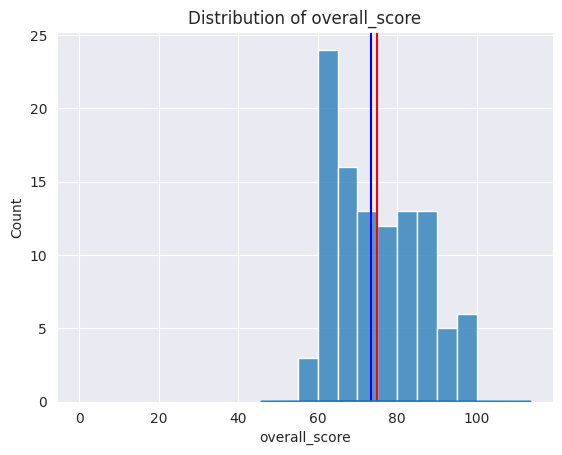

In [20]:
histplot_with_central_tendency('overall_score', title='Distribution of overall_score')
sns.kdeplot(data=df,x='overall_score')




In [21]:
print(f"Skewness: {df['overall_score'].skew()}")
print(f"Kurtosis: {df['overall_score'].kurt()}")

Skewness: 0.40046996784837363
Kurtosis: -0.9249640046288201


# **Data analysis**

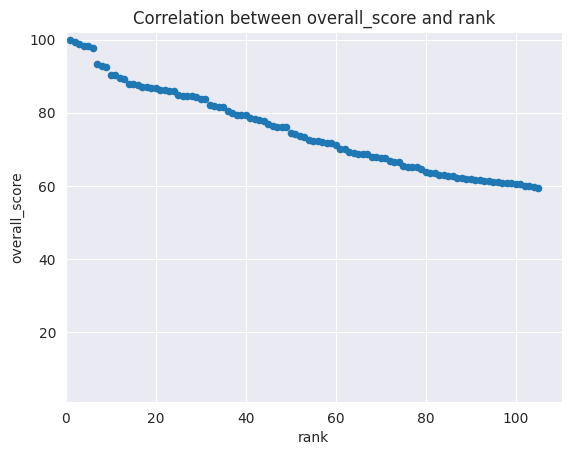

In [22]:
df.plot.scatter(
    x='rank',
    y='overall_score',
    title='Correlation between overall_score and rank'
)

plt.xlim(0)
plt.ylim(1)
plt.show()